In [1]:
import scarf
from scarf.plotting import FeatureRef

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_8K_pbmc_citeseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)

In [2]:
[wnn_graph] = ds.list_artifacts(
    scope="datastore",
    kind="integrated_graph",
    operation="integrate_assays",
    parameters={"method": "wnn"},
    complete_only=True,
)
[wnn_umap] = ds.list_artifacts(
    scope="datastore",
    kind="embedding",
    operation="run_umap",
    inputs={"graph": wnn_graph},
    complete_only=True,
)
[wnn_clusters] = ds.list_artifacts(
    scope="datastore",
    kind="cluster_labels",
    operation="run_leiden_clustering",
    inputs={"graph": wnn_graph},
    complete_only=True,
)

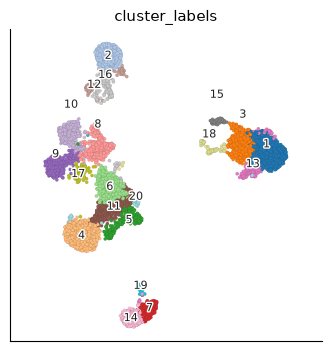

In [3]:
ds.plots.embedding(
    layout=wnn_umap,
    color_by=wnn_clusters,
    legend_loc="on_data",
)

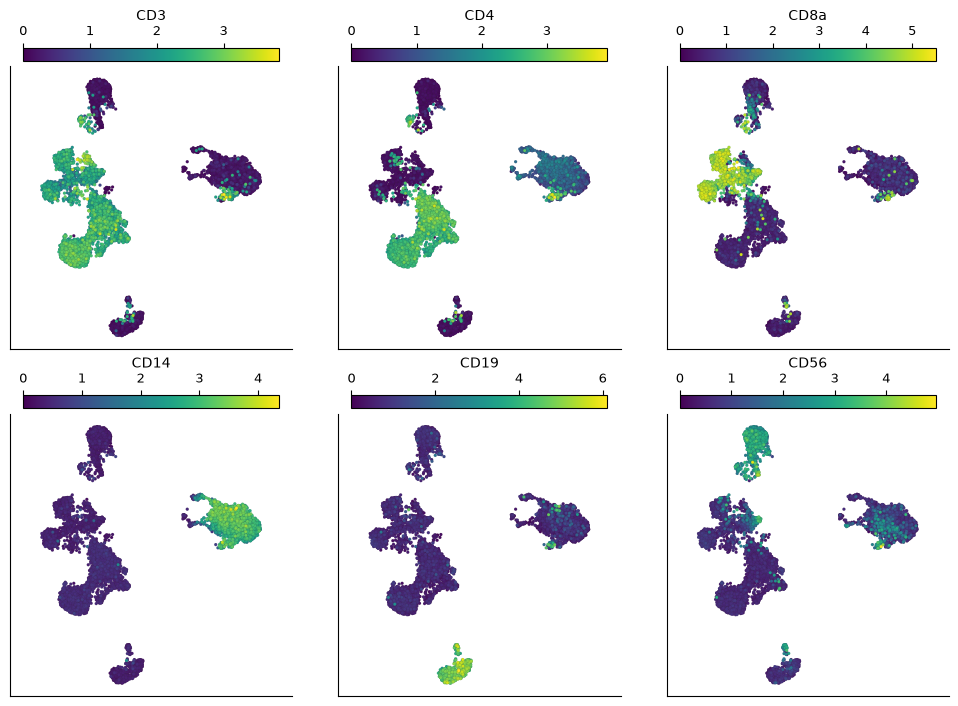

In [4]:
protein_panel = [
    FeatureRef(marker, assay="ADT", by="id", label=marker)
    for marker in ("CD3", "CD4", "CD8a", "CD14", "CD19", "CD56")
]
ds.plots.embedding(
    layout=wnn_umap,
    color_by=protein_panel,
    n_columns=3,
    sort_values=True,
)